In [ ]:
import matplotlib.pyplot as plt
import numpy as np
#import math as mt
import tensorflow as tf
import tensorflow_datasets as tfds

In [ ]:
! pip install tensorflow_datasets -U

Requirement already up-to-date: tensorflow_datasets in /usr/local/lib/python3.6/dist-packages (4.2.0)


In [ ]:
 (train_data, val_data, test_data), metadata = tfds.load(
    'deep_weeds',
     split=['train[:60%]', 
           'train[60%:80%]', 
           'train[80%:]'],
    with_info=True,
    as_supervised=True)

Dataset deep_weeds downloaded and prepared to /root/tensorflow_datasets/deep_weeds/3.0.0. Subsequent calls will reuse this data.


**show Examples of train and test**

In [ ]:
# show examples 
def show_examples():
  examples_training = tfds.visualization.show_examples(
   train_data,
    metadata)
  print('test')
  test_examples = tfds.visualization.show_examples(
   test_data,
    metadata)
  return examples_training, test_examples

In [ ]:
# L'ensemble de données  comprend 9 classes.
num_classes = metadata.features['label'].num_classes
print(num_classes)

9


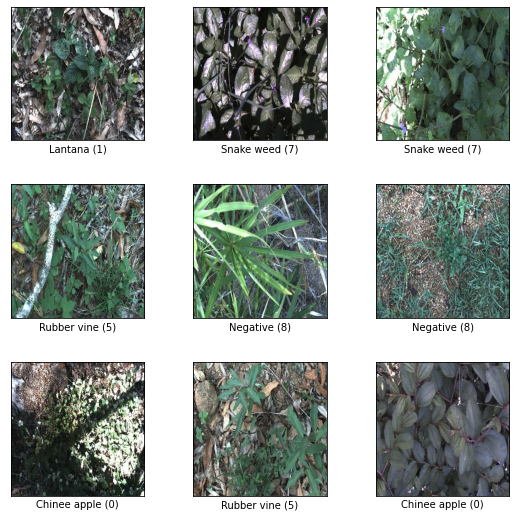

test


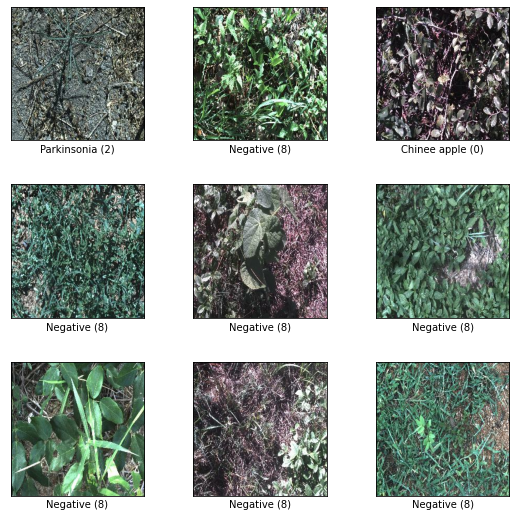

(<Figure size 648x648 with 9 Axes>, <Figure size 648x648 with 9 Axes>)

In [ ]:
show_examples()

**Data Augmenataion**

In [ ]:
def flip(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    return image, label

In [ ]:
def normalize_image(img, label):
  image = tf.image.resize(img, [224, 224])/255
  return image, label

In [ ]:
def color(image, label):
   
    image = tf.image.random_brightness(image, max_delta=0.5) # add  the brightness of images by a random factor.
    image = tf.image.random_hue(image, max_delta=0.1) 
    image = tf.image.random_contrast(image, lower=0.7, upper=1.3) #  # Adjust the contrast of an image or images by a random factor.
    #image = tf.image.random_crop(image, [crop_size,crop_size,3], seed=None, name=None)
    return image, label

**Rotate** : One of the most simplest augmentations is rotating the image 90 degrees. For this we can use the rot90 function of Tensorflow. To get a new random rotation for each image we need to use a random function from Tensorflow itself. Random functions from Tensorflow are evaluated for every input, functions from numpy or basic python only once which would result in a static augmentation.

In [ ]:
import math
def rotate(image, label):
  delta = tf.random.uniform([], minval = math.radians(-360), maxval = math.radians(360), dtype=tf.float32)
  image = tf.image.rot90(image, tf.dtypes.cast(delta, tf.int32))
  print('test')
  return image, label

In [ ]:
'''def preprocess_and_augment(img, label): 
  img, label = normalize_image(img,label)
  img, label = brightness(img,label)
  img, label = flip(img,label)
  img, label = rotate(img, label)
  return img,label'''

'def preprocess_and_augment(img, label): \n  img, label = normalize_image(img,label)\n  img, label = brightness(img,label)\n  img, label = flip(img,label)\n  img, label = rotate(img, label)\n  return img,label'

In [ ]:
augmentations = [normalize_image, color, flip, rotate] 

In [ ]:
for augment in augmentations:
  train_data_gen = train_data.map(augment, num_parallel_calls = 4).cache().batch(32)

test


In [ ]:
validation_data = val_data.map(normalize_image).cache().batch(32)

In [ ]:
test_data_genarator = test_data.map(normalize_image).cache().batch(32)

In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from keras.optimizers import Adam
from tensorflow.keras.layers import Flatten, Input


In [ ]:
 def creatmodel():

  INITIAL_LR = 0.0001
  image_input = Input((224, 224, 3))
  resnet = tf.keras.applications.ResNet50(include_top=False, weights="imagenet")

  model = tf.keras.Sequential(
        [image_input,
        resnet,
        GlobalAveragePooling2D(),
        Flatten(),
        Dense(num_classes, activation="sigmoid")])

  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR), loss="sparse_categorical_crossentropy", metrics="accuracy")
  print("model est !")
  return model

In [ ]:
def creat_model():
  inp_shape = (224,224,3)
  model = tf.keras.Sequential()
  model.add(tf.keras.Input((224,224,3)))
  model.add(tf.keras.applications.InceptionV3(
    include_top=False, 
    weights='imagenet',
    input_shape=inp_shape))

  model.add(GlobalAveragePooling2D(name='avg_pool'))
  model.add(Flatten())
  model.add(tf.keras.layers.Dense(num_classes, activation='sigmoid'))
  #model.add(Dropout(0.5))
  print('La création de model')
  
  return model

In [ ]:
model = creat_model()

La création de model


In [ ]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
inception_v3 (Functional)    (None, 5, 5, 2048)        21802784  
_________________________________________________________________
avg_pool (GlobalAveragePooli (None, 2048)              0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 2048)              0         
_________________________________________________________________
dense (Dense)                (None, 9)                 18441     
Total params: 21,821,225
Trainable params: 21,786,793
Non-trainable params: 34,432
_________________________________________________________________


In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
! pip install livelossplot

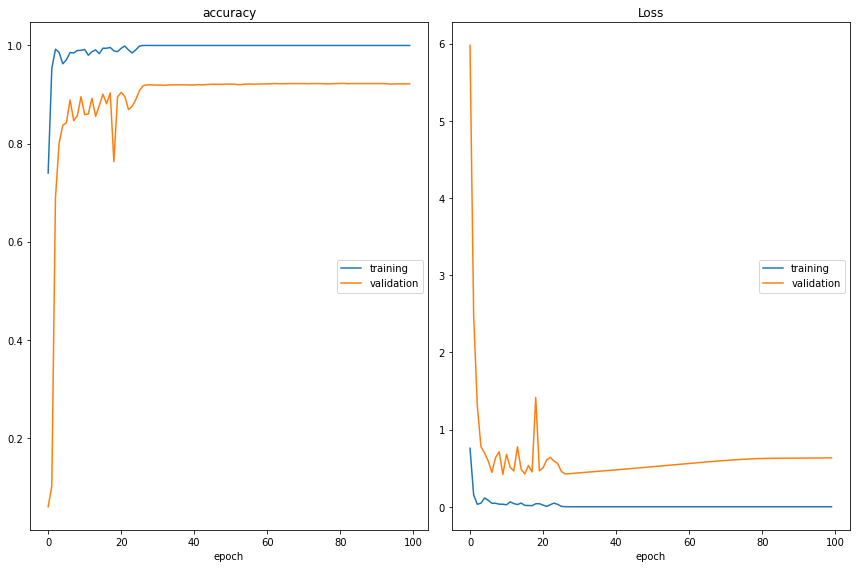

accuracy
	training         	 (min:    0.740, max:    1.000, cur:    1.000)
	validation       	 (min:    0.060, max:    0.923, cur:    0.922)
Loss
	training         	 (min:    0.000, max:    0.757, cur:    0.000)
	validation       	 (min:    0.419, max:    5.976, cur:    0.634)


In [ ]:
from livelossplot import PlotLossesKeras

history = model.fit(x = train_data_gen, 
          epochs=100, batch_size = 32, 
          callbacks=[PlotLossesKeras()], 
          validation_data = validation_data)

In [ ]:
model.save('model_resnet.h5')

In [ ]:
# evaluate the model 
def eval():
    metrics = model.evaluate(
        x=test_data_genarator,
        batch_size=32,
        verbose=1,
        sample_weight=None
    )
    print ('Loss: {:.3f}, Accuracy: {:.3f}'.format(metrics[0], metrics[1]))

In [ ]:
eval()

110/110 [==============================] - 15s 127ms/step - loss: 0.7244 - accuracy: 0.9083
Loss: 0.724, Accuracy: 0.908


In [ ]:
filepath = '/content/model_resnet.h5'
model = tf.keras.models.load_model(filepath)

In [ ]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
img = image.load_img("/content/ln.jpg", target_size=(224, 224, 3))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
images = np.vstack([x])
predictions = model.predict(images)
classe = np.argmax(predictions, axis=1)
labels = weeds_label = ["Chinee apple", "Lantana", "Parkinsonia", "Parthenium", "Prickly acacia", "Rubber vine", "Siam weed", "Snake weed", "Negatives"]

print(predictions[0])
print(predictions[0][int(classe[0])])
print(list(labels)[int(classe[0])])

FileNotFoundError: ignored